First Five Rows
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Shape of Dataset
(768, 9)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies         

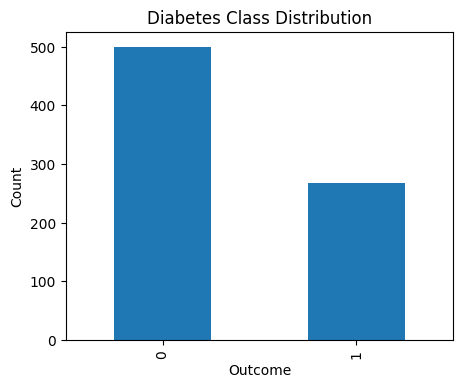

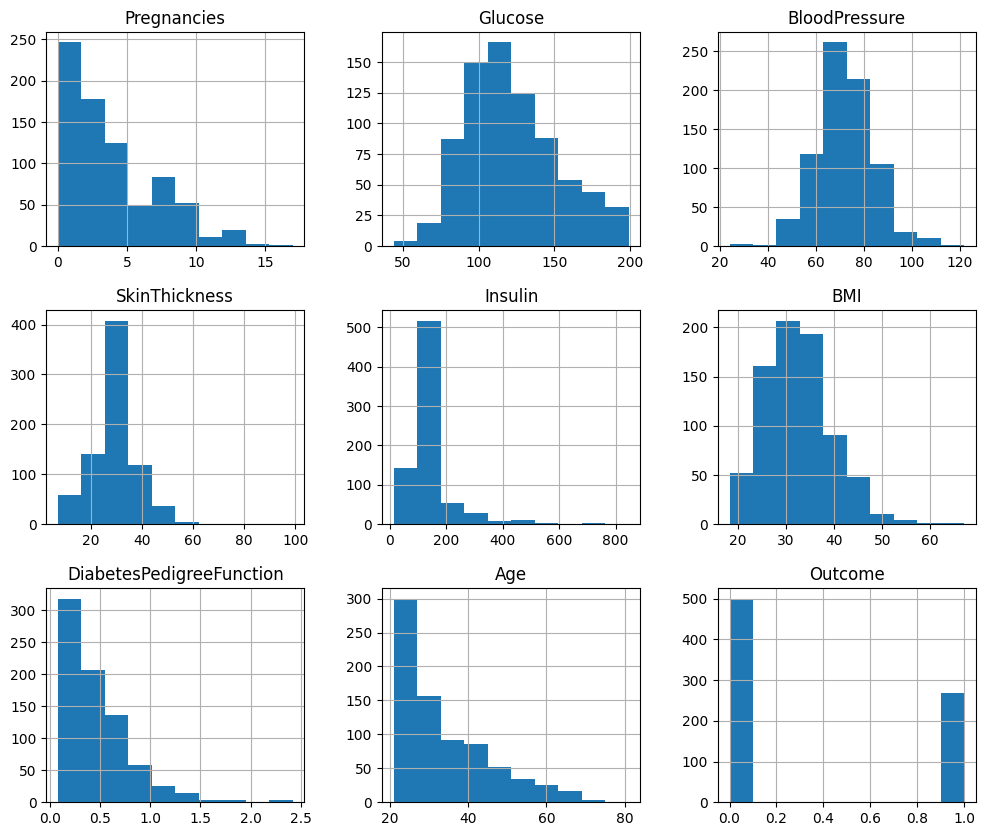

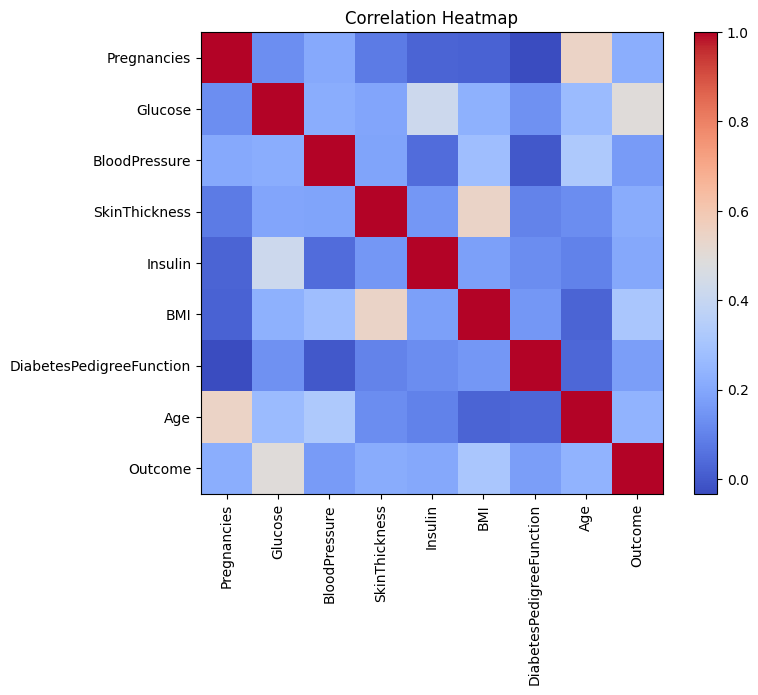

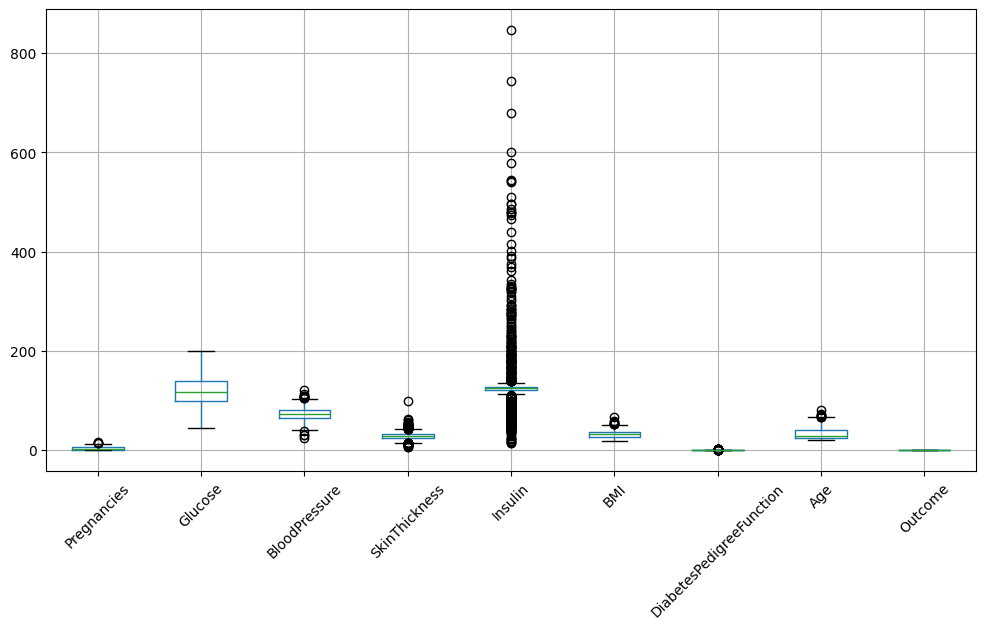


Accuracy : 0.7402597402597403
Precision : 0.631578947368421
Recall : 0.6545454545454545
F1 Score : 0.6428571428571429

Confusion Matrix
[[78 21]
 [19 36]]

Classification Report
              precision    recall  f1-score   support

           0       0.80      0.79      0.80        99
           1       0.63      0.65      0.64        55

    accuracy                           0.74       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.74      0.74      0.74       154


Patient is Not Diabetic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [1]:
# ===============================
# Diabetes Prediction Project
# ===============================

# Step 1: Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# ===============================
# Step 2: Load Dataset
# ===============================

df = pd.read_csv("diabetes.csv")

# ===============================
# Step 3: Display Dataset
# ===============================

print("First Five Rows")
print(df.head())

print("\nShape of Dataset")
print(df.shape)

print("\nDataset Information")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

# ===============================
# Step 4: Check Missing Values
# ===============================

print("\nMissing Values")
print(df.isnull().sum())

# ===============================
# Step 5: Check Duplicate Values
# ===============================

print("\nDuplicate Rows")
print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

# ===============================
# Step 6: Replace Zero Values
# ===============================

columns = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

for col in columns:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

# ===============================
# Step 7: Exploratory Data Analysis
# ===============================

# Class Distribution

plt.figure(figsize=(5,4))
df['Outcome'].value_counts().plot(kind='bar')
plt.title("Diabetes Class Distribution")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

# Histograms

df.hist(figsize=(12,10))
plt.show()

# Correlation Heatmap

import matplotlib.pyplot as plt

corr = df.corr()

fig, ax = plt.subplots(figsize=(8,6))
cax = ax.imshow(corr, cmap='coolwarm')

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)

ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)

fig.colorbar(cax)

plt.title("Correlation Heatmap")

plt.show()

# Boxplots

df.boxplot(figsize=(12,6))
plt.xticks(rotation=45)
plt.show()

# ===============================
# Step 8: Feature and Target
# ===============================

X = df.drop("Outcome", axis=1)

y = df["Outcome"]

# ===============================
# Step 9: Feature Scaling
# ===============================

scaler = StandardScaler()

X = scaler.fit_transform(X)

# ===============================
# Step 10: Train Test Split
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ===============================
# Step 11: Train Model
# ===============================

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# ===============================
# Step 12: Prediction
# ===============================

y_pred = model.predict(X_test)

# ===============================
# Step 13: Evaluation
# ===============================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

print("\nAccuracy :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1 Score :", f1)

print("\nConfusion Matrix")

print(cm)

print("\nClassification Report")

print(classification_report(y_test, y_pred))

# ===============================
# Step 14: Predict New Patient
# ===============================

sample = np.array([[2,120,70,20,79,25.5,0.5,30]])

sample = scaler.transform(sample)

prediction = model.predict(sample)

if prediction[0] == 1:
    print("\nPatient is Diabetic")
else:
    print("\nPatient is Not Diabetic")